In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

from skimage.feature import local_binary_pattern

import os

import warnings
warnings.filterwarnings("ignore")

# Cats and Dogs Dataset

In [2]:
# for kaggle api
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
# downaloding data from kaggle
!kaggle competitions download -c dogs-vs-cats -p ./dogs_vs_cats

 98% 793M/812M [00:04<00:00, 47.3MB/s]
100% 812M/812M [00:04<00:00, 181MB/s] 


In [4]:
!unzip /content/dogs_vs_cats/dogs-vs-cats.zip

!unzip -q train.zip

Archive:  /content/dogs_vs_cats/dogs-vs-cats.zip
  inflating: sampleSubmission.csv    
  inflating: test1.zip               
  inflating: train.zip               


In [5]:
os.makedirs("data/train/cats", exist_ok=True)
os.makedirs("data/train/dogs", exist_ok=True)

!mv train/cat.* data/train/cats/
!mv train/dog.* data/train/dogs/

In [5]:
from PIL import Image
def preprocessing(data_path,img_size=(64,64)):
    x = []
    y = []

    for cls in os.listdir(data_path):
        cls_path = os.path.join(data_path,cls)

        if os.path.isdir(cls_path):
            label = 0 if cls=="cats" else 1 # label for out data

            for img_name in os.listdir(cls_path):
                img_path = os.path.join(cls_path,img_name)

                #load and converto to RGB
                img = Image.open(img_path).convert("RGB")

                #resize
                img = img.resize(img_size)

                #np array
                img_arr = np.array(img)

                #normalize
                img_arr = img_arr / 255.0

                img_arr = img_arr.flatten()

                x.append(img_arr)
                y.append(label)

    return x,y


data_path = "/content/data/train"
x,y = preprocessing(data_path) # we get x and y from out function they are python list

# converting x and y to numpy array to feed into the model
np_x = np.array(x)
np_y = np.array(y)

np_x.shape,np_y.shape

# ((25000, 12288), (25000,))
# 25000  images(samples)
# flatten size = 64,64,3 = 12288

((25000, 12288), (25000,))

# Color Histogram

In [6]:
def color_hist(img,bins=10):
    # img must be numpy array in RGB for color Histogram
    hist = []
    for i in range(3): #for each channel(R,G,B)
        channel_hist = np.histogram(img[:,:,i],bins=bins,range=(0,1))[0]
        hist.extend(channel_hist)
    # we first convert histogram to np array and then divide by sum of all bins of the histogram
    hist = np.array(hist) / np.sum(hist)  # normalzie
    return hist

# for 10 bins 3 channel  ==> 30 diminsion features map

# Edge Features

In [7]:
import cv2
def edgg_features(img):
    # as img in srmalized(0-1) we convert it back to (0-255) and mek it 8 bit integer as open cv require it
    # and then we conver RGB-> Gray(as edge detection work on intensity change )
    gray  = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_RGB2GRAY)


    # Sobel -> Sobel operator is a gradient filter it detects edges by measuring change in pixel intensity.
    # Sobel(img,output_type(64bitFP),derivative_order,kernel_size(sobel filter))
    sobelx = cv2.Sobel(gray,cv2.CV_64F,1,0,ksize=3) # edges in horizontal direction
    sobely = cv2.Sobel(gray,cv2.CV_64F,0,1,ksize=3) # edges in vertical direction

    #Gradient magnitude combining horizontal + vertical gradient)
    # Pythagoras theorem in 2D gradient space->sqrt(Gx^2 + Gy^2)
    # as Gx and Gy can be negative we use sqrt
    sobel_mag = np.sqrt(sobelx**2 + sobely**2)

    # flatten
    # mean give -> average edge intensity
    # sd give  -> variation of edge intensity
    return np.array([np.mean(sobel_mag),np.std(sobel_mag)])

# Texture Features(LBP)

### LBP histogram captures micro-features(patteren) in an Image

* How it works **for each pixel**:

  1. Take the pixel and its **P neighbors** on a circle of radius **R**.
  2. Compare neighbors with center pixel:

     * Neighbor ≥ center → 1
     * Neighbor < center → 0
  3. Concatenate 0s and 1s → a **binary number** → decimal value → **LBP code**

* Example (3×3 neighborhood, P=8):

```
Neighbor pixels:  [120, 130, 115, 140, 125, 110, 105, 135]
Center pixel:      120(the pixel we chose become center pixel)
Binary code:       01110110 → decimal 118
```

* `method="uniform"`:

  * Only considers **patterns with ≤2 transitions** (0→1 or 1→0) as “uniform”.
  * Reduces the number of histogram bins → more compact feature.

* **Result:** `lps` is a 2D array of same size as gray image, with **LBP codes** per pixel.




In [8]:
# LBP code → value between 0 and max code (P+2 for uniform method)
# for P=8 value in 2D array of lps is between (0,8+2)->(0,10)

def texture_features(img,P=8,R=1):
    # similar like above
    gray = cv2.cvtColor((img*255).astype(np.uint8),cv2.COLOR_RGB2GRAY)
    # we extract local binary patterent using skimage built in funciton
    # methood = "uniform" -> it is used to reproduce the number of bins
    # lps -> is a 2D array of same size as gray image, with LBP codes per pixel.
    lps = local_binary_pattern(gray,P,R,method="uniform")

    # bin size = P+2 -> 8+2 -> 10  so each histgram cover all possible code of lps
    hist,_ = np.histogram(lps,bins=int(P+2),range=(0,P+2))
    # Divide each bin by total number of pixels
    hist = hist / hist.sum() #normalize
    return hist

In [9]:
# we combine all the 3 features
def extract_features(img):
    ch = color_hist(img)
    ef = edgg_features(img)
    tf = texture_features(img)
    return np.concatenate([ch,ef,tf])  # concatinating all 2 features

In [10]:
def extract_features_for_pipeline(x):
     # X is a list or array of images (64x64x3)
    features_list = []
    # we conver flatten images back to (64,64,3)
    for img in x:
        # if img is flattened then we reshape reshape
        if img.ndim == 1:
            img = img.reshape(64, 64, 3)

        features = extract_features(img)  #otherwise we img to as it is
        features_list.append(features)
    return np.array(features_list)


feature_arr = extract_features_for_pipeline(np_x)
print(feature_arr.shape)

(25000, 42)


In [11]:
import pandas as pd

# column names
columns = [f"color_{i}" for i in range(30)] + ["edge_mean", "edge_std"] + [f"lbp_{i}" for i in range(10)]

df_features = pd.DataFrame(feature_arr, columns=columns)
df_features.head()

,color_0,color_1,color_2,color_3,color_4,color_5,color_6,color_7,color_8,color_9,...,lbp_0,lbp_1,lbp_2,lbp_3,lbp_4,lbp_5,lbp_6,lbp_7,lbp_8,lbp_9
0,0.012126,0.122965,0.052490,0.049154,0.048340,0.018880,0.007650,0.007812,0.009115,0.004801,...,0.036865,0.081787,0.052979,0.132812,0.218750,0.160156,0.054443,0.076904,0.077393,0.107910
1,0.012044,0.022135,0.008708,0.018148,0.064453,0.138753,0.020182,0.016276,0.024495,0.008138,...,0.059082,0.085938,0.058350,0.111084,0.175537,0.138916,0.075928,0.075439,0.085205,0.134521
2,0.002197,0.008952,0.009277,0.004964,0.010579,0.048584,0.089681,0.117188,0.036540,0.005371,...,0.034424,0.062012,0.059082,0.138428,0.248047,0.155029,0.064209,0.069580,0.061035,0.108154
3,0.000000,0.014811,0.059408,0.026367,0.015706,0.029378,0.048503,0.069499,0.040609,0.029053,...,0.071533,0.087646,0.065430,0.113525,0.187988,0.106445,0.068115,0.079590,0.078857,0.140869
4,0.034668,0.125081,0.042725,0.011393,0.009440,0.009196,0.014242,0.027751,0.047445,0.011393,...,0.060303,0.082520,0.067383,0.126953,0.191650,0.125488,0.064453,0.075684,0.077393,0.128174


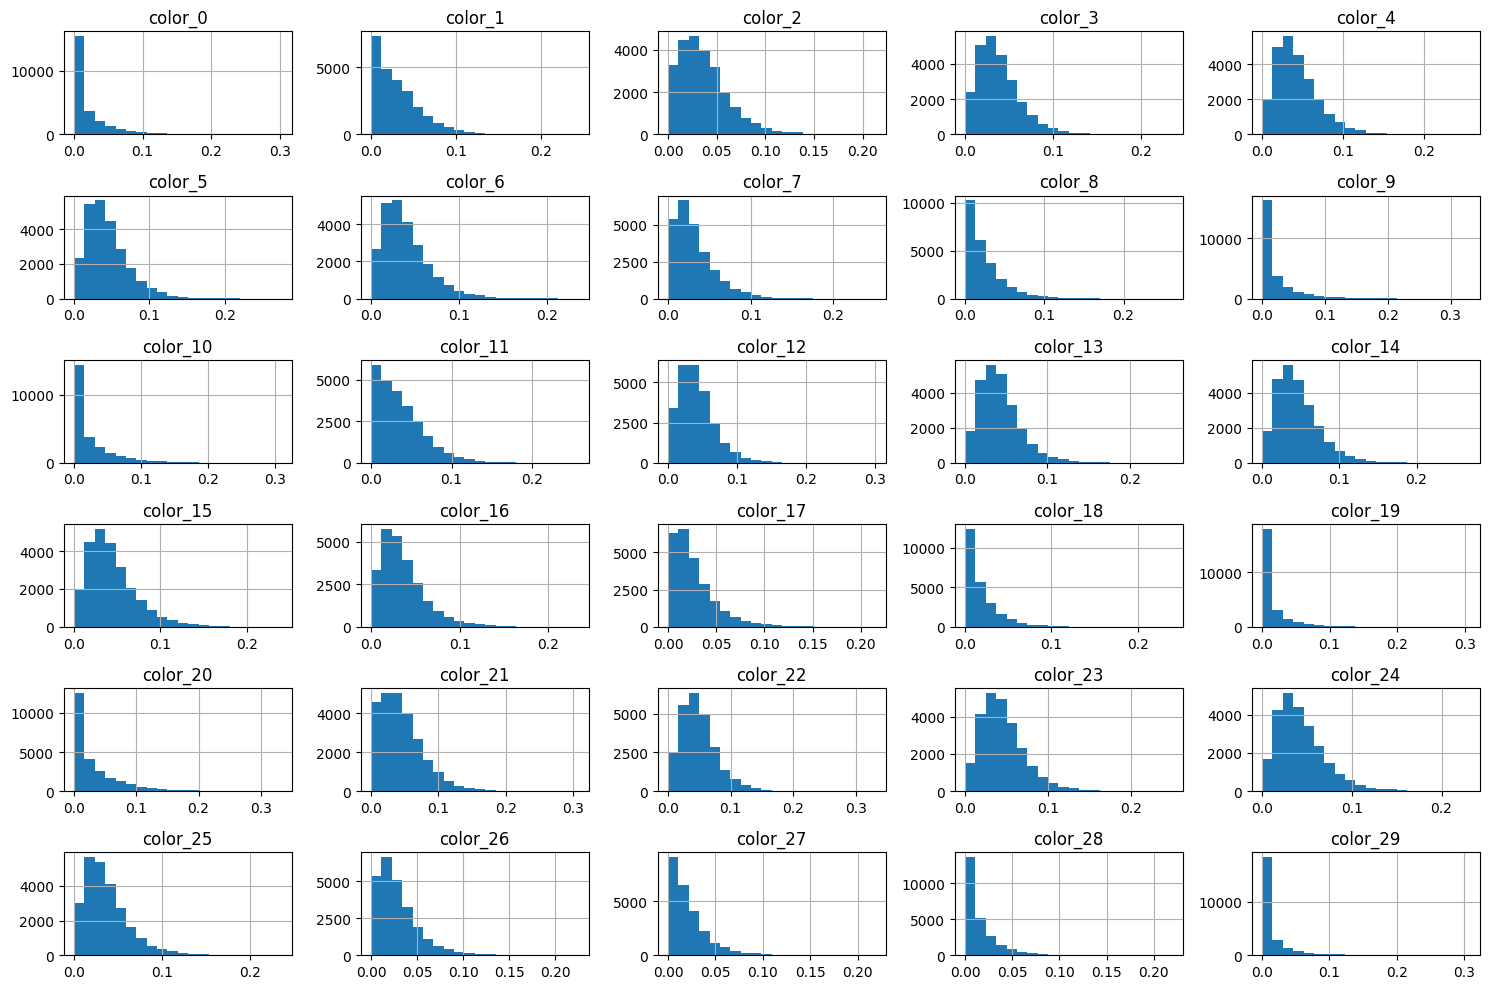

In [12]:
# for 10 bins 3 channel  ==> 30 diminsion colour histogram features(that why 30 columns)
df_features.iloc[:, :30].hist(bins=20, figsize=(15,10))
plt.tight_layout()
plt.show()

# x-axis = the value of the normalized histogram bin(0–1)
# y-axis = number of images that have that particular histogram bin value within that range

# How to interpret it
# Peaks in a histogram → many images have that bin value in that range
# Flat histogram → that bin value is evenly spread across images
# Differences between bins/channels → tell you about color distribution in your dataset
# For example:
# If color_0 (Red channel, first bin) has a peak near 0 → many images have low intensity red pixels
# If color_25 (Blue channel, last bin) has a peak near 1 → many images have high intensity blue pixels
# This is useful for color-based feature analysis in image classification.

In [13]:
# feature_arr = it give better information about images and is low dimesnion(42)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer


function_transformer = FunctionTransformer(extract_features_for_pipeline) # our custom function

# Support Vector Machine

In [14]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix

pipeline_svm = Pipeline([
    ("features",function_transformer), # custom feature extraction
    ("scaler",StandardScaler()), # scale features
    ("svm",SVC(kernel='rbf', C=1.0, gamma='scale')) # classifier
])

x_train,x_test,y_train,y_test = train_test_split(np_x,np_y,test_size=0.2,random_state=42)

Accuracy score: 0.6828
Precision Score: {precision}
Recall Score: 0.6170974155069583


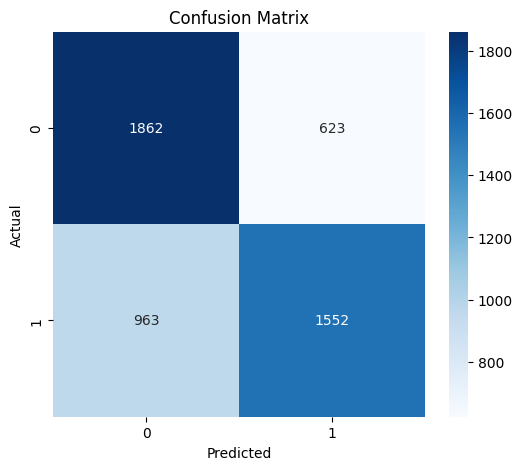

In [15]:
pipeline_svm.fit(x_train,y_train)
y_pred = pipeline_svm.predict(x_test)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
cm = confusion_matrix(y_test,y_pred)


print(f"Accuracy score: {accuracy}")
print("Precision Score: {precision}")
print(f"Recall Score: {recall}")
cm

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [16]:
import joblib
joblib.dump(pipeline_svm,"svm_pipeline")

['svm_pipeline']

# Random Forest

In [20]:
pipeline_rf = Pipeline([
    ("features",function_transformer), # custom feature extraction
    ("scaler",StandardScaler()), # scale features
    ("svm",RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)) # classifier
])

x_train,x_test,y_train,y_test = train_test_split(np_x,np_y,test_size=0.2,random_state=42)

Accuracy score: 0.6648
Precision Score: {precision}
Recall Score: 0.5956262425447316


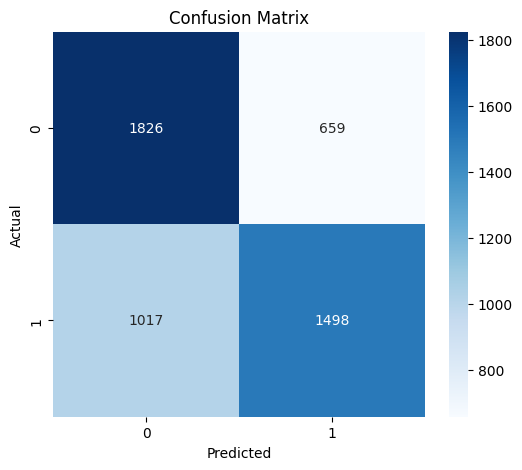

In [18]:
pipeline_rf.fit(x_train,y_train)
y_pred = pipeline_rf.predict(x_test)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
cm = confusion_matrix(y_test,y_pred)

print(f"Accuracy score: {accuracy}")
print("Precision Score: {precision}")
print(f"Recall Score: {recall}")


plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [19]:
import joblib
joblib.dump(pipeline_rf,"rf_pipeline")


['rf_pipeline']

# K-Nearest Neighbour

In [22]:
pipeline_knn = Pipeline([
    ("features",function_transformer), # custom feature extraction
    ("scaler",StandardScaler()), # scale features
    ("svm",KNeighborsClassifier(n_neighbors=5)) # classifier
])

x_train,x_test,y_train,y_test = train_test_split(np_x,np_y,test_size=0.2,random_state=42)

Accuracy score: 0.6172
Precision Score: {precision}
Recall Score: 0.5669980119284295


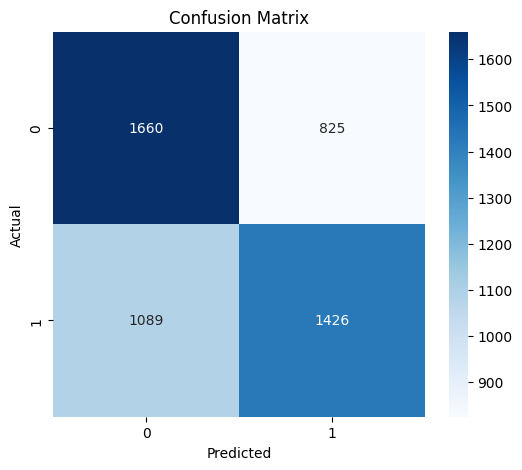

In [23]:
pipeline_knn.fit(x_train,y_train)
y_pred = pipeline_knn.predict(x_test)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
cm = confusion_matrix(y_test,y_pred)

print(f"Accuracy score: {accuracy}")
print("Precision Score: {precision}")
print(f"Recall Score: {recall}")


plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [24]:
import joblib
joblib.dump(pipeline_knn,"knn_pipeline")


['knn_pipeline']